# Introduction to atomman: Thermodynamic tools

*added version 1.??*

The atomman.thermo submodule collects a variety of supporting tools related to analyzing equilibrium atomic configurations and computing thermodynamic properties. This Notebook outlines the thermodynamic models that are included.

Most of these tools were primarily created in support of specific iprPy calculations, but they have basic functionality that may be useful otherwise. I'm welcome to suggestions for additional features and refinement of these tools.

In [10]:
# Standard Python libraries
import datetime

# http://www.numpy.org/
import numpy as np

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc

# https://matplotlib.org/
import matplotlib.pyplot as plt
%matplotlib inline

# Show atomman version
print('atomman version =', am.__version__)

# Show date of Notebook execution
print('Notebook executed on', datetime.date.today())

atomman version = 1.5.2
Notebook executed on 2026-07-01


## 1. Idealgas

The state of an ideal gas is defined for the IdealGas class using

- __T__ the temperature.
- __V__ the volume.
- __m__ the masses for each unique atom type.
- __N__ the number of atoms of each unique atom type.

In [27]:
ig = am.thermo.IdealGas(T=400,
                        V=uc.set_in_units(100, 'angstrom')**3,
                        m=[39.948],
                        N=[10000])

Once the state is defined, derivative properties can be obtained.

- __rho__ is the atomic density.
- __Λ__ is the de Broglie thermal wavelength(s).
- __c__ is the fractional concentration of each species.
- __S__ is the total entropy.
- __F__ is the total free energy?

In [16]:
Ntotal = ig.N.sum()
print('rho =', uc.get_in_units(ig.rho, 'angstrom^-3'), 'angstrom^-3')
print('Λ =', ig.Λ)
print('c =', ig.c)
print('S =', uc.get_in_units(ig.S, 'eV/K') / Ntotal, 'eV/K/atom')
print('F =', uc.get_in_units(ig.F, 'eV') / Ntotal, 'eV/atom')

rho = 0.01 angstrom^-3
Λ = [0.13810913]
c = [1.]
S = 0.0011240711058463954 eV/K/atom
F = -0.39792444276568706 eV/atom


## 2. EinsteinSolid

The Einstein solid model is defined here using

- __theta__ the Einstein temperature in K.
- __H0__ the 0K per-atom enthalpy energy of the structure.  Identical to the cohesive energy of the structure at P = 0, T = 0K.

In [17]:
einstein = am.thermo.EinsteinSolid(theta=300, H0=-2.91)

Once defined, the following methods allow for estimating properties at different tempertaures

- __H()__ is the enthalpy: H = H0 + (3 kB θ) / (exp(θ / T) - 1)
- __Cv()__ is the constant volume heat capacity: cV = (3 kB (θ / T)^2 exp(θ / T)) / (exp(θ / T) - 1)^2
- __G__ is the Gibbs free energy: G = H0 + 3/2 kB θ + 3 kB T ln(1 - exp(- θ / T))

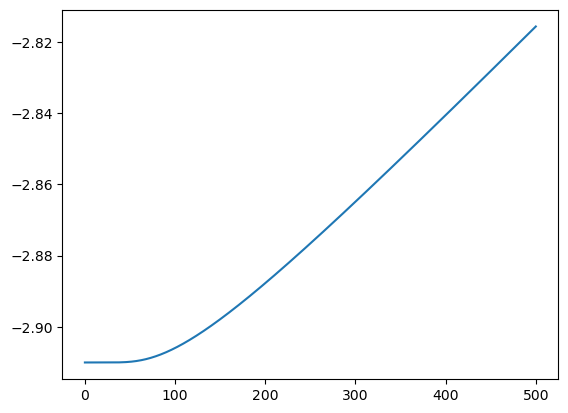

In [18]:
T = np.linspace(0, 500, 1000)
plt.plot(T, einstein.H(T))

F:\Python-packages\atomman\atomman\thermo\EinsteinSolid.py:103: RuntimeWarning: overflow encountered in square
  return 3 * kB * x**2 * np.exp(x) / (np.exp(x) - 1)**2


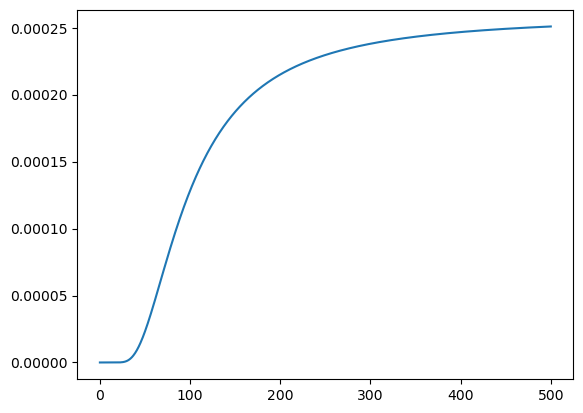

In [19]:
T = np.linspace(0, 500, 1000)
plt.plot(T, einstein.Cv(T))

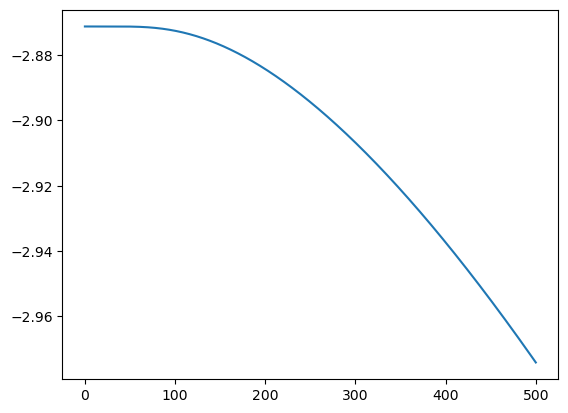

In [20]:
T = np.linspace(0, 500, 1000)
plt.plot(T, einstein.G(T))

## 3. UhlenbeckFordModel

The UhlenbeckFordModel provides estimates of thermodynamic states associated with liquids modeled with the Uhlenbeck-Ford model (ufm) interatomic potential.  This potential was thoroughly characterized by [Paula Leite, Santos-Florez, and de Koning, Phys Rev E, 96, 32115 (2017)](https://doi.org/10.1103/PhysRevE.96.032115), and this class was constructed based on the tables and code in that paper's supported materials.

A thermodynamic state can be defined with the UhlenbeckFordModel class using

- __sigma__ the Uhlenbeck Ford length scale parameter.
- __p__ the Uhlenbeck Ford energy scaling parameter.  Allowed values are 1, 25, 50, 75, and 100.
- __temperature__ the simulation temperature.
- __density__ the numerical density of the liquid: natoms / volume.  Cannot be given with volume.
- __volume__ the volume to use to compute density.  Cannot be given with density.
- __natoms__ the number of atoms in the given volume, which is used to compute density.  Default value is 1.

In [21]:
ufm = am.thermo.UhlenbeckFordModel(sigma=1.5, p=50, temperature=400, volume=uc.set_in_units(100, 'angstrom')**3, natoms=10000)

The basic thermo properties that can then be computed are

- __pressure()__ the absolute pressure of the system.
- __free_energy()__ the per-atom excess free energy of the system.

In [25]:
print('pressure =', uc.get_in_units(ufm.pressure(), 'MPa'), 'MPa')
print('free_energy =', uc.get_in_units(ufm.free_energy(), 'eV'), 'eV')

pressure = 112.15164813190488 MPa
free_energy = 0.02932618170611671 eV


__NOTE__ that the free energy returned by this class is the excess free energy!  Add the associated ideal gas free energy to it to make it an absolute free energy!

In [26]:
# ig above used the same T, V, and N, so it is already compatible
F_ig = ig.F / Ntotal

print('F =', uc.get_in_units(ufm.free_energy() + F_ig, 'eV'), 'eV')

F = -0.36859826105957033 eV
